In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("case4_hr_kmeans_1000.csv")
df.head()

,YearsExperience,SkillsCount,ProjectsCompleted,Certifications
0,1,7,1,1
1,0,7,1,1
2,1,7,1,1
3,0,4,1,1
4,0,4,3,0


In [3]:
df.columns

Index(['YearsExperience', 'SkillsCount', 'ProjectsCompleted',
       'Certifications'],
      dtype='object')

In [4]:
X = df[['YearsExperience', 'SkillsCount', 'ProjectsCompleted',
       'Certifications']]

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

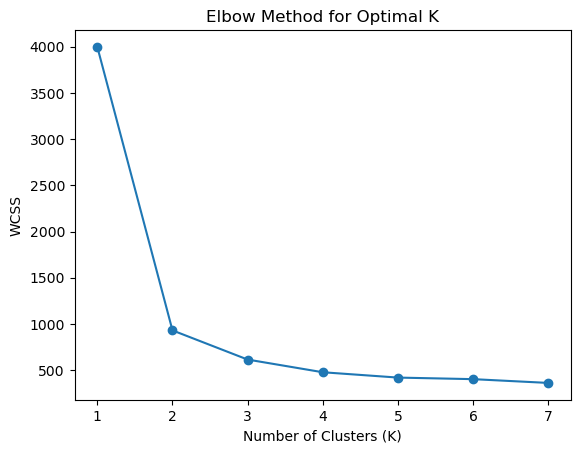

In [10]:
wcss = []

for k in range (1,8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,8), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df

,YearsExperience,SkillsCount,ProjectsCompleted,Certifications,Cluster
0,1,7,1,1,2
1,0,7,1,1,2
2,1,7,1,1,2
3,0,4,1,1,2
4,0,4,3,0,2
...,...,...,...,...,...
994,13,25,25,7,1
995,13,24,15,6,1
996,12,19,16,9,1
997,12,23,31,3,1


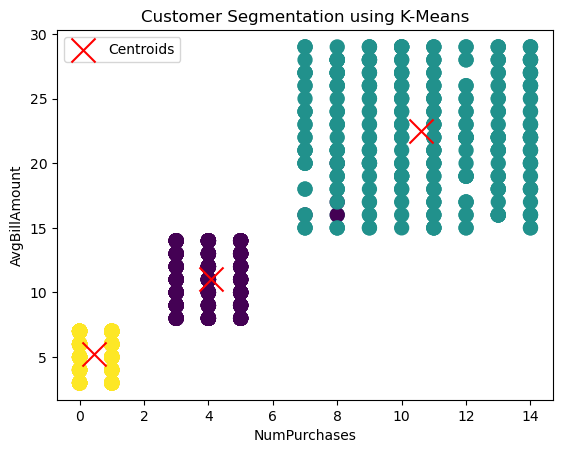

In [8]:
#Visualize the cluster
plt.figure()

plt.scatter(
    df['YearsExperience'], df['SkillsCount'], c=df['Cluster'], cmap='viridis', s=100)
plt.xlabel("NumPurchases")
plt.ylabel("AvgBillAmount")
plt.title("Customer Segmentation using K-Means")

#Now plotting centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:,0], centroids[:,1], s=300, c='red', marker='x', label='Centroids')
plt.legend()
plt.show()